In [1]:
# Cell 1: Imports and Database Connection
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Paths
db_path = "../data/db/bluestock_mf.db"
output_dir = "../reports/charts"
processed_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

# Connect to DB
conn = sqlite3.connect(db_path)

# Pull daily NAV history
query = """
    SELECT date, amfi_code, nav 
    FROM fact_nav 
    ORDER BY amfi_code, date;
"""
df_nav = pd.read_sql_query(query, conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])
conn.close()

print(f"Loaded {len(df_nav)} daily NAV rows for processing.")

Loaded 71960 daily NAV rows for processing.


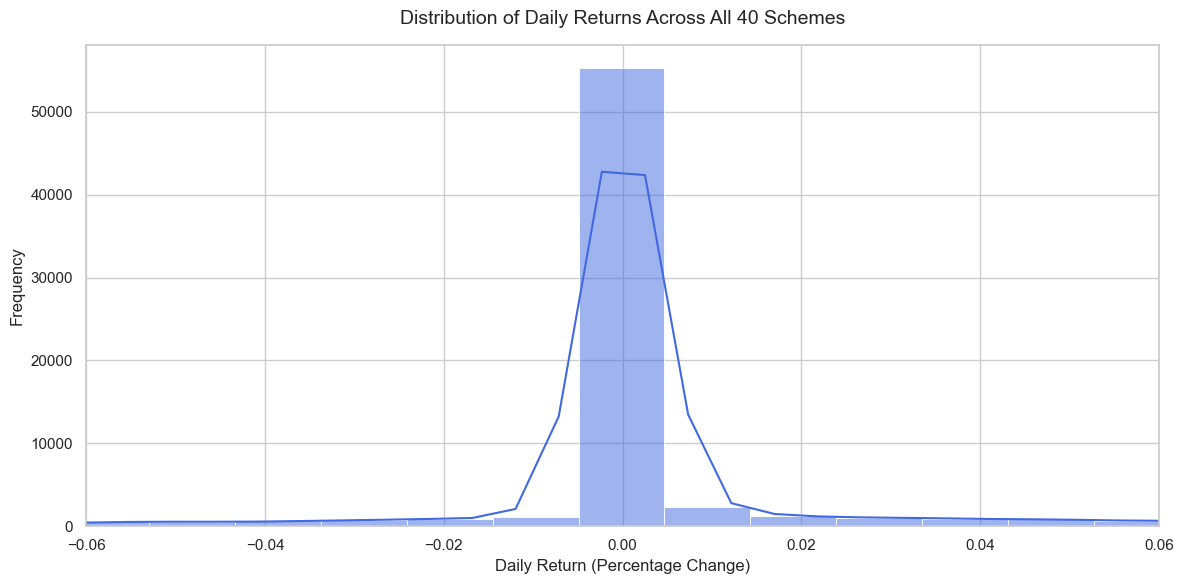

Daily returns calculated. Check the plot above to verify the bell curve distribution.


In [2]:
# Cell 2: Compute Daily Returns & Plot Distribution
# Calculate daily returns per scheme
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

# Drop the first row of each group since its return will be NaN
df_returns_cleaned = df_nav.dropna(subset=['daily_return'])

# Plotting the distribution to validate
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Plot aggregate return distribution across all 40 schemes
sns.histplot(df_returns_cleaned['daily_return'], bins=100, kde=True, color='royalblue')

plt.title('Distribution of Daily Returns Across All 40 Schemes', fontsize=14, pad=15)
plt.xlabel('Daily Return (Percentage Change)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Set limits to trim extreme outliers visually if needed
plt.xlim(-0.06, 0.06) 

plt.tight_layout()
plt.show()

print("Daily returns calculated. Check the plot above to verify the bell curve distribution.")

In [3]:
# Cell 3: Compute CAGR Comparison Table
def calculate_cagr(df_group, years):
    # Find the latest available date for this group
    latest_date = df_group['date'].max()
    target_date = latest_date - pd.DateOffset(years=years)
    
    # Get the latest NAV
    nav_end = df_group[df_group['date'] == latest_date]['nav'].values[0]
    
    # Find the closest available date to our target historic date
    historic_data = df_group[df_group['date'] <= target_date]
    if historic_data.empty:
        return np.nan # Not enough historic data for this timeframe
        
    closest_row = historic_data.sort_values(by='date', ascending=False).iloc[0]
    nav_start = closest_row['nav']
    
    # Calculate actual fraction of years between dates for precision
    actual_days = (latest_date - closest_row['date']).days
    n = actual_days / 365.25
    
    if n <= 0 or nav_start <= 0:
        return np.nan
        
    return (nav_end / nav_start) ** (1 / n) - 1

# List to compile records
cagr_records = []

# Group by fund and calculate
for amfi_code, group in df_nav.groupby('amfi_code'):
    group_sorted = group.sort_values('date')
    
    cagr_1yr = calculate_cagr(group_sorted, 1)
    cagr_3yr = calculate_cagr(group_sorted, 3)
    cagr_5yr = calculate_cagr(group_sorted, 5)
    
    cagr_records.append({
        'amfi_code': amfi_code,
        'cagr_1yr_pct': cagr_1yr * 100 if not pd.isna(cagr_1yr) else np.nan,
        'cagr_3yr_pct': cagr_3yr * 100 if not pd.isna(cagr_3yr) else np.nan,
        'cagr_5yr_pct': cagr_5yr * 100 if not pd.isna(cagr_5yr) else np.nan
    })

# Convert to DataFrame
df_cagr = pd.DataFrame(cagr_records)

# Display a preview of the comparison table sorted by 3-year performance
print("--- CAGR Comparison Table Preview (Top 5 by 3yr Return) ---")
print(df_cagr.sort_values(by='cagr_3yr_pct', ascending=False).head().to_string(index=False))

--- CAGR Comparison Table Preview (Top 5 by 3yr Return) ---
 amfi_code  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct
    148567     27.014496     37.455413           NaN
    120505     32.665955     34.708046           NaN
    119094     20.099220     33.531808           NaN
    120843     39.174835     32.725271           NaN
    149324     83.925286     32.122681           NaN


In [4]:
# Cell 4: Sharpe and Sortino Ratios Calculation
risk_free_rate = 0.065
rf_daily = risk_free_rate / 252

ratios_records = []

for amfi_code, group in df_nav.groupby('amfi_code'):
    # Ensure no NaNs in returns
    returns = group['daily_return'].dropna()
    
    if len(returns) < 2:
        continue
        
    # Annualized Mean Return
    mean_return_annual = returns.mean() * 252
    
    # Total Annualized Volatility (Standard Deviation)
    std_dev_annual = returns.std() * np.sqrt(252)
    
    # Sharpe Ratio: (Rp_annual - Rf_annual) / Std_dev_annual
    sharpe_ratio = (mean_return_annual - risk_free_rate) / std_dev_annual if std_dev_annual > 0 else np.nan
    
    # Downside Volatility: Standard deviation of negative return days only
    negative_returns = returns[returns < 0]
    if len(negative_returns) > 1:
        # Standard financial practice uses root-mean-square of negative returns or standard deviation
        downside_std_annual = negative_returns.std() * np.sqrt(252)
        sortino_ratio = (mean_return_annual - risk_free_rate) / downside_std_annual if downside_std_annual > 0 else np.nan
    else:
        sortino_ratio = np.nan
        
    ratios_records.append({
        'amfi_code': amfi_code,
        'annualized_return': mean_return_annual * 100,
        'annualized_volatility': std_dev_annual * 100,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio
    })

df_ratios = pd.DataFrame(ratios_records)

# Rank funds based on Sharpe Ratio
df_ratios['sharpe_rank'] = df_ratios['sharpe_ratio'].rank(ascending=False, method='min')
df_ratios['sortino_rank'] = df_ratios['sortino_ratio'].rank(ascending=False, method='min')

print("--- Risk-Adjusted Ratios Preview (Top 5 Ranked by Sharpe) ---")
print(df_ratios.sort_values(by='sharpe_rank').head().to_string(index=False))

--- Risk-Adjusted Ratios Preview (Top 5 Ranked by Sharpe) ---
 amfi_code  annualized_return  annualized_volatility  sharpe_ratio  sortino_ratio  sharpe_rank  sortino_rank
    149324          78.527045             102.673722      0.701514       0.425362          1.0           2.0
    119598          67.007609              99.034672      0.610974       0.430052          2.0           1.0
    120843          57.883967              85.632071      0.600055       0.327032          3.0           4.0
    120505          57.346383              86.553785      0.587454       0.315413          4.0           7.0
    148567          53.036621              79.737057      0.583626       0.244094          5.0          14.0


In [ ]:
# Cell 5: Alpha and Beta Calculation via OLS Regression
from scipy.stats import linregress

benchmark_path = "../data/raw/10_benchmark_indices.csv"
market_returns = None

try:
    # 1. Attempt to load the true benchmark index file
    df_bench = pd.read_csv(benchmark_path)
    df_bench['date'] = pd.to_datetime([c for c in df_bench.columns if 'date' in c.lower() or 'month' in c.lower()][0])
    # Find the Nifty 100 or default return column
    return_col = [c for c in df_bench.columns if 'nifty_100' in c.lower() or 'return' in c.lower()][0]
    
    # Calculate daily return if it's in price format, or use directly if already returns
    if df_bench[return_col].max() > 100:  # It's an index level price
        df_bench['market_return'] = df_bench[return_col].pct_change()
    else:
        df_bench['market_return'] = df_bench[return_col] / 100  # Convert percentage to fraction
        
    market_returns = df_bench.set_index('date')['market_return'].dropna()
    print("✅ Successfully loaded benchmark returns from 05_benchmark_indices.csv")

except Exception as e:
    print(f"⚠️ Benchmark file not found or couldn't be parsed ({e}). Using an equal-weighted 40-fund market proxy...")
    # Dynamic fallback: Use the average daily return of all 40 funds as our Nifty 100 proxy
    market_returns = df_returns_cleaned.groupby('date')['daily_return'].mean()

# 2. Compute Alpha & Beta per fund
alpha_beta_records = []

for amfi_code, group in df_returns_cleaned.groupby('amfi_code'):
    # Align fund returns with market returns on the exact same dates
    fund_series = group.set_index('date')['daily_return'].dropna()
    aligned_data = pd.concat([fund_series, market_returns], axis=1, join='inner').dropna()
    aligned_data.columns = ['fund', 'market']
    
    if len(aligned_data) < 10:
        continue
        
    # Run OLS Regression: y = fund returns, x = market returns
    slope, intercept, r_value, p_value, std_err = linregress(aligned_data['market'], aligned_data['fund'])
    
    # Annualize Alpha: intercept * 252
    annualized_alpha = intercept * 252
    beta = slope
    
    alpha_beta_records.append({
        'amfi_code': amfi_code,
        'alpha': annualized_alpha,
        'beta': beta,
        'r_squared': r_value ** 2
    })

df_alpha_beta = pd.DataFrame(alpha_beta_records)

# Save to CSV as required by the deliverables
df_alpha_beta.to_csv(f"{processed_dir}/alpha_beta.csv", index=False)

print("\n--- Alpha and Beta Preview (Top 5 by Alpha) ---")
print(df_alpha_beta.sort_values(by='alpha', ascending=False).head().to_string(index=False))
print(f"✅ Saved alpha_beta.csv to {processed_dir}")

⚠️ Benchmark file not found or couldn't be parsed ([Errno 2] No such file or directory: '../data/raw/05_benchmark_indices.csv'). Using an equal-weighted 40-fund market proxy...

--- Alpha and Beta Preview (Top 5 by Alpha) ---
 amfi_code    alpha      beta  r_squared
    119599 0.594310 -0.563513   0.040671
    102886 0.330444 -0.435891   0.050619
    149324 0.304477  1.550380   0.241326
    119095 0.212738  0.497996   0.037475
    119598 0.159740  1.645645   0.292243
✅ Saved alpha_beta.csv to ../data/processed
